# Initialize token

In [99]:
# Written by Lucie Reymondet, UCSD Scripps Institution of Oceanography
# Code to download EUMETSAT data using the EUMETSAT Data Access Client (EUMDAC) Python library and Data Tailor

import eumdac
import datetime
import shutil
import time
import fnmatch
import requests
from IPython.core.display import HTML
import time
import os
import zipfile
import json
import xarray as xr

# Insert personal key and secret
consumer_key = '2WA_GJftbSnmegkQ6gNBxSqo_Foa'
consumer_secret = 'khEoQY_BjsQD1QDZ83ntHE9gIBoa'

# Generate token, by default validity = 24h
credentials = (consumer_key, consumer_secret)
token = eumdac.AccessToken(credentials, validity = 86400, cache=False)
try:
    print(f"This token '{token}' expires {token.expiration}")
except requests.exceptions.HTTPError as error:
    print(f"Error when tryng the request to the server: '{error}'")

# Initialize DataStore and DataTailor instances
datastore = eumdac.DataStore(token)
datatailor = eumdac.DataTailor(token)


This token 'c32912ec-01af-3563-8da1-7ac5a97a4770' expires 2025-11-05 11:50:21.451342


## List products of interest

In [110]:
# Select and filter a collection

# Desired collection
# coll = 'EO:EUM:DAT:0665' # MTG FCI HR
coll = 'EO:EUM:DAT:0662' # MTG FCI NR
# coll = 'EO:EUM:DAT:0678' # MTG FCI cloud mask
# coll = 'EO:EUM:DAT:MSG:HRSEVIRI' # MSG SEVIRI
# coll = 'EO:EUM:DAT:MSG:CLM' # MSG SEVIRI

# Display search options for the selected collection
try:
    selected_collection = datastore.get_collection(coll) 
    print(f"{selected_collection} - {selected_collection.title}")
    print(f"Description: {selected_collection.abstract}")
    print(f"Metadata: {selected_collection.metadata}")
    print(f"Search options: {selected_collection.search_options} \n")
except eumdac.datastore.DataStoreError as error:
    print(f"Error related to the data store: '{error}'")
except eumdac.collection.CollectionError as error:
    print(f"Error related to the collection: '{error}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")

# Filter criteria
# bounding_box = '11, -41, 21, -31' #(W, S, E, N) 
start = datetime.datetime(2025, 6, 1, 0, 0)
end = datetime.datetime(2025, 9, 1, 0, 0)
# satellite = 'MTI1' # For HRSEVIRI: 'MSGn' where n=1,2,3,4, For FCI: 'MTIn' where n=1,2,3,4 (only MTI1 operational as of Nov 2025)

# Retrieve and display products that match our filter
products = selected_collection.search(
    # geo='POLYGON(({}))'.format(','.join(["{} {}".format(*coord) for coord in geometry])),
    # bbox=bounding_box,
    dtstart=start, dtend=end,
    # sat=satellite
    )
try:
    print(f'{products.total_results} products found for the given filters')
    for product in products:
        print(product)
except eumdac.collection.CollectionError as error:
    print(f"Error related to the collection: '{error}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")


EO:EUM:DAT:0662 - FCI Level 1c Normal Resolution Image Data - MTG - 0 degree
Description: The rectified (Level 1c) Meteosat FCI full disc image data in normal spatial (FDHSI) resolution. The FCI instrument consists of 16 imaging spectral channels ranging from 0.4 µm to 13.3 µm with the channel at 3.8 µm having an extended dynamic range dedicated to fire monitoring. The spatial resolution is 1km for visible and near-infrared channels and 2 km for infrared channels. FCI Level 1c rectified radiance dataset consists of a set of files that contain the level 1c science data rectified to a reference grid together with the auxiliary data associated with the processing configuration and the quality assessment of the dataset.
Metadata: {'geometry': {'type': 'Polygon', 'coordinates': [[[-79, 79], [-79, -79], [79, -79], [79, 79], [-79, 79]]]}, 'properties': {'type': 'Properties', 'kind': 'Dataset', 'identifier': 'EO:EUM:DAT:0662', 'title': 'FCI Level 1c Normal Resolution Image Data - MTG - 0 degre

KeyboardInterrupt: 

## Download, unzip, crop, resample/project and save to netcdf

In [108]:
# Run time for this code is ~ 30 minutes per day in 15min samples

# from satpy import Scene
# from pyresample import create_area_def
# from pathlib import Path
# import re
# import glob
# import pandas as pd

if coll == 'EO:EUM:DAT:MSG:HRSEVIRI':
    dataset_id = 'IR_108'
    calibration_id = 'brightness_temperature'
    format = 'nat'
    reader = 'seviri_l1b_native'
elif coll == 'EO:EUM:DAT:MSG:CLM':
    dataset_id = 'cloud_mask'
    calibration_id = '' # categorical classification, no calibration attribute
    format = 'grb'
    reader = 'seviri_l2_grib'

# lon_min, lon_max = 10.0, 21.0
# lat_min, lat_max = -42.0, -30.0

# area_def = create_area_def(
#     area_id='geographic_area', # sets the name for the CF grid_mapping variable.
    
#     description = 'Region overlapping the SWOT AdAC QUICCHE campaign', # optional

#     projection = {'proj': 'latlong', 'datum': 'WGS84'}, # equivalently projection = 'EPSG:4326'. Parameterizes the CF grid_mapping variable.
    
#     # width=250, height=250,        # number of pixels in the x and y directions, depending on desired resolution
#     resolution = (0.04, 0.04),    # or specify a pixel size (in projection units) e.g. 0.05 degrees per pixel
#     # shape = (250, 250)          # or tuple (height, width)

#     area_extent=(lon_min, lat_min, lon_max, lat_max) # bounding box in projection coordinates, units are implied through projection argument
# )

zip_dir = "/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/zip/"
os.makedirs(zip_dir, exist_ok=True)
# unzip_dir = "/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/unzip/"
# os.makedirs(unzip_dir, exist_ok=True)
# nc_dir = "/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/nc/"
# os.makedirs(nc_dir, exist_ok=True)

for product in products:
    t0 = time.time()
    # print("product = ", product)
    try:
        ## Download product in full to zip_dir folder
        with product.open() as fsrc:
            product_name  = os.path.splitext(os.path.basename(fsrc.name))[0]
            # print("product name = ", product_name)
            dst_path = os.path.join(zip_dir, os.path.basename(fsrc.name))
            # print("dst_path = ", dst_path)
            with open(dst_path, mode='wb') as fdst:
                shutil.copyfileobj(fsrc, fdst)
            # print(f'Downloaded')
        
        # ## Unzip to unzip_dir folder
        # with zipfile.ZipFile(dst_path, 'r') as zip_ref:
        #     # print(zip_ref.namelist())
        #     zip_ref.extractall(unzip_dir)
        # # print(f"Unzipped")

        # ## Load scene, crop and resample to ROI
        # filepath = os.path.join(unzip_dir, f"{product_name}.{format}")
        # scn = Scene(filenames=[filepath], reader=reader)
        # if calibration_id=='':
        #     scn.load([dataset_id])
        # else:
        #     scn.load([dataset_id], calibration=calibration_id)
        # local_scn = scn.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
        # resampled_scn = local_scn.resample(area_def)

        # ## Save to netcdf
        # ## CF-compliant method (heavier files)
        # # resampled_scn.save_datasets(
        # #     writer='cf',                                        # CF-compliant NetCDF writer
        # #     datasets=[dataset_id],                              # which dataset(s) to save
        # #     filename=os.path.join(nc_dir,f"{product_name}.nc"), # output file path
        # # )
        # ## Simple data array method (only for 'latlong' projection)
        # da = resampled_scn[dataset_id].data
        # lons = resampled_scn[dataset_id].coords['x'].data
        # lats = resampled_scn[dataset_id].coords['y'].data
        # ds = xr.Dataset(
        #     {dataset_id: (["lat","lon"], da)},
        #     coords={"lat": lats,
        #             "lon":lons}
        # )
        # ds.to_netcdf(os.path.join(nc_dir,f"{product_name}.nc"))
        # # print("Resampled and saved")

        # ## Remove all contents of the zip and unzip folders before next iteration
        # for file in Path(zip_dir).glob("*"):
        #     if file.is_file():
        #         file.unlink()
        #     elif file.is_dir():
        #         shutil.rmtree(file)
        # # print(f"Emptied zip folder")
        # for file in Path(unzip_dir).glob("*"):
        #     if file.is_file():
        #         file.unlink()
        #     elif file.is_dir():
        #         shutil.rmtree(file)
        # # print(f"Emptied unzip folder")

        print(f"Time elapsed for product : {(time.time()-t0):.1f} seconds.")

    except eumdac.product.ProductError as error:
        print(f"Error related to the product '{product}' while trying to download it: '{error.msg}'")
    except requests.exceptions.ConnectionError as error:
        print(f"Error related to the connection: '{error}'")
    except requests.exceptions.RequestException as error:
        print(f"Unexpected error: {error}")
    
print('All products processed.')

Time elapsed for product : 36.4 seconds.
Time elapsed for product : 35.2 seconds.
Time elapsed for product : 35.2 seconds.
Time elapsed for product : 36.8 seconds.


KeyboardInterrupt: 

In [ ]:

        ## Load scene, crop and resample to ROI
        filepath = os.path.join(unzip_dir, f"{product_name}.{format}")
        scn = Scene(filenames=[filepath], reader="seviri_l1b_native")

        scn.load([dataset_id], calibration=calibration_id)
        local_scn = scn.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
        resampled_scn = local_scn.resample(area_def)

        ## Save to netcdf
        ## CF-compliant method (heavier files)
        # resampled_scn.save_datasets(
        #     writer='cf',                                        # CF-compliant NetCDF writer
        #     datasets=[dataset_id],                              # which dataset(s) to save
        #     filename=os.path.join(nc_dir,f"{product_name}.nc"),   # output file path
        # )
        ## Simple data array method (only for 'latlong' projection)
        da = resampled_scn[dataset_id].data
        lons = resampled_scn[dataset_id].coords['x'].data
        lats = resampled_scn[dataset_id].coords['y'].data
        ds = xr.Dataset(
            {dataset_id: (["lat","lon"], da)},
            coords={"lat": lats,
                    "lon":lons}
        )
        ds.to_netcdf(os.path.join(nc_dir,f"{product_name}.nc"))
        # print("Resampled and saved")

        ## Remove all contents of the zip and unzip folders before next iteration
        for file in Path(zip_dir).glob("*"):
            if file.is_file():
                file.unlink()
            elif file.is_dir():
                shutil.rmtree(file)
        # print(f"Emptied zip folder")
        for file in Path(unzip_dir).glob("*"):
            if file.is_file():
                file.unlink()
            elif file.is_dir():
                shutil.rmtree(file)
        # print(f"Emptied unzip folder")

        print(f"Time elapsed for product : {(time.time()-t0)/60:.1f} minutes.")

    except eumdac.product.ProductError as error:
        print(f"Error related to the product '{product}' while trying to download it: '{error.msg}'")
    except requests.exceptions.ConnectionError as error:
        print(f"Error related to the connection: '{error}'")
    except requests.exceptions.RequestException as error:
        print(f"Unexpected error: {error}")
    
print('All products processed.')

## Sanity check snapshot

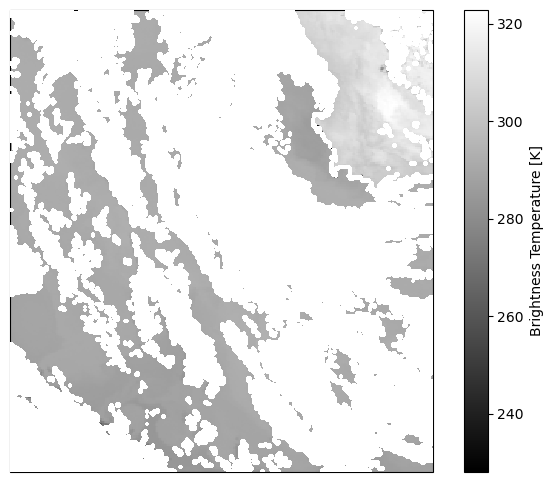

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import xarray as xr

da = xr.open_dataarray("/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/nc/MSG4-SEVI-MSG15-0100-NA-20230302141243.649000000Z-NA.nc")
CLM = xr.open_dataarray("/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/nc/MSG4-SEVI-MSGCLMK-0100-0100-20230302141500.000000000Z-NA.nc")

CLM = xr.where(CLM==2,1,0)
alpha = CLM.clip(0,1).fillna(0)

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(da.lon, da.lat, da, cmap='gray', transform=ccrs.PlateCarree())
clm = ax.pcolormesh(da.lon, da.lat, np.ones_like(CLM.data), alpha=alpha.data, color='white',shading='auto', zorder=10)
ax.coastlines()
plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')
plt.show()

## Concatenate along time dimension

In [93]:
from pandas import to_datetime

def load_and_concat(pattern_str, prefix, dirin):
    """Load EUMETSAT files, normalize time (seconds → 0) or round to neareset quarter hour, and concatenate."""
    pattern = re.compile(pattern_str)
    files = sorted(glob.glob(os.path.join(dirin, f"{prefix}*.nc")))
    if not files:
        raise FileNotFoundError(f"No matching files found for {prefix} in {dirin}")

    times = []
    for f in files:
        basename = os.path.basename(f)
        match = pattern.search(basename)
        if not match:
            raise ValueError(f"Could not extract start time from filename: {basename}")
        timestamp_str = match.group(1)
        timestamp = pd.to_datetime(timestamp_str, format="%Y%m%d%H%M%S")
        
        # timestamp = timestamp.floor("min").replace(second=0) # Normalize: seconds → 0
        timestamp = timestamp.round("15min") # Round to nearest quarter hour
        times.append(timestamp)

    datasets = [xr.open_dataset(f) for f in files]
    combined = xr.concat(datasets, dim=xr.Variable("time", times))
    return combined

# --- Load both products and combine snapshots along time dimension
IR = load_and_concat(r"MSG4-SEVI-MSG15-0100-NA-(\d{8}\d{6})", "MSG4-SEVI-MSG15-0100-NA-", nc_dir)
CLM = load_and_concat(r"MSG4-SEVI-MSGCLMK-0100-0100-(\d{8}\d{6})", "MSG4-SEVI-MSGCLMK-0100-0100-", nc_dir)

# --- Keep only timestamps common to both ---
times = IR.time.values
common_times = np.intersect1d(IR["time"].values, CLM["time"].values)
IR = IR.sel(time=common_times)
CLM = CLM.sel(time=common_times)

# --- Save result ---
IR.to_netcdf(f'HRSEVIRI{to_datetime(times[0]).strftime("%Y%m%d_%H%M")}-{to_datetime(times[-1]).strftime("%Y%m%d_%H%M")}.nc')
CLM.to_netcdf(f'CLMSEVIRI{to_datetime(times[0]).strftime("%Y%m%d_%H%M")}-{to_datetime(times[-1]).strftime("%Y%m%d_%H%M")}.nc')

print(IR)
print(CLM)

<xarray.Dataset> Size: 139MB
Dimensions:  (time: 420, lat: 300, lon: 275)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-03-02T14:15:00 ... 2023-03-07
  * lat      (lat) float64 2kB -30.02 -30.06 -30.1 ... -41.9 -41.94 -41.98
  * lon      (lon) float64 2kB 10.02 10.06 10.1 10.14 ... 20.86 20.9 20.94 20.98
Data variables:
    IR_108   (time, lat, lon) float32 139MB 283.1 283.3 283.3 ... 281.4 281.3
<xarray.Dataset> Size: 277MB
Dimensions:     (time: 420, lat: 300, lon: 275)
Coordinates:
  * time        (time) datetime64[ns] 3kB 2023-03-02T14:15:00 ... 2023-03-07
  * lat         (lat) float64 2kB -30.02 -30.06 -30.1 ... -41.9 -41.94 -41.98
  * lon         (lon) float64 2kB 10.02 10.06 10.1 10.14 ... 20.9 20.94 20.98
Data variables:
    cloud_mask  (time, lat, lon) float64 277MB 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0


## Animate

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x1000 -pix_fmt rgba -framerate 2 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -b 10000k -y HRSEVIRI20230302_1415-20230307_0000.mp4


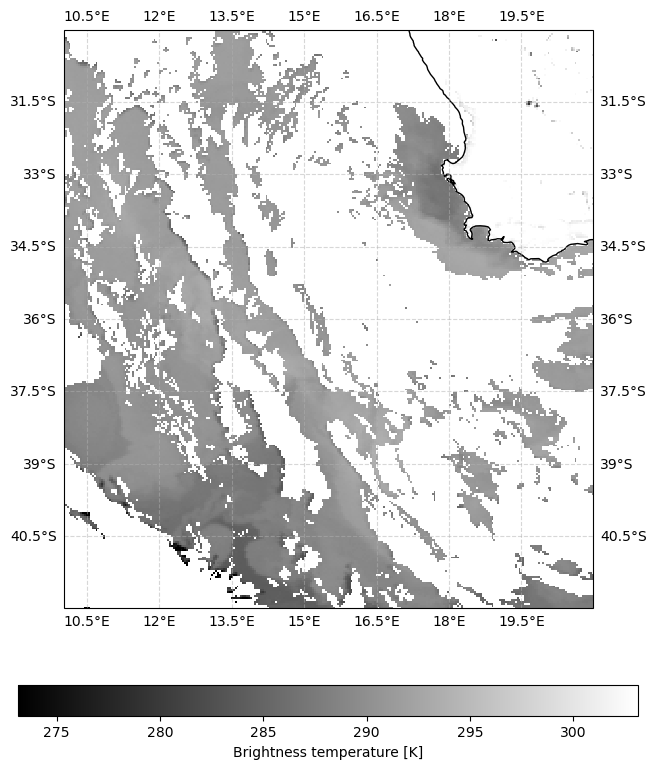

In [98]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import numpy as np
from pandas import to_datetime

IR=xr.open_dataarray("/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/HRSEVIRI20230302_1415-20230307_0000.nc") #- 273.15
CLM=xr.open_dataarray("/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/CLMSEVIRI20230302_1415-20230307_0000.nc")

lat, lon = IR.lat.values, IR.lon.values
Lat, Lon = np.meshgrid(lon,lat)
times = IR.time.values

IR_masked = IR.where(CLM!=2)

# CLM = xr.where(CLM==2,1,0)
# alpha = CLM.clip(0,1).fillna(0)

vmin = 273.15 # 0°C
vmax = 30 + 273.15 #30°C
# vmin = IR_masked.min().item()
# vmax = IR_masked.max().item()
# vmin = IR.min().item()
# vmax = IR.max().item()

fig, ax = plt.subplots(figsize=(10,10), dpi=100, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8, alpha=0.5,linestyle='--')

# ir = ax.pcolormesh(Lat, Lon, IR.isel(time=0).data,
#                    vmin=vmin, vmax=vmax, cmap='gray')
# clm = ax.pcolormesh(Lat, Lon, np.ones_like(IR.isel(time=0).data), 
#                     alpha=alpha.isel(time=0).data,color='white',shading='auto',zorder=10)
irm = ax.pcolormesh(Lat, Lon, IR_masked.isel(time=0).data,
                   vmin=vmin, vmax=vmax, cmap='gray')

cb = plt.colorbar(irm,ax=ax,orientation='horizontal',pad=0.1,shrink=0.8)
cb.set_label(r"Brightness temperature [K]")

plt.tight_layout

def update(frame):
    # ir.set_array(IR.isel(time=frame).data)
    # clm.set_alpha(alpha.isel(time=frame).data)
    irm.set_array(IR_masked.isel(time=frame).data)
    return ir
ani = FuncAnimation(fig, update, frames=len(times), blit=False)

ani.save(
    f'HRSEVIRI{to_datetime(times[0]).strftime("%Y%m%d_%H%M")}-'
    f'{to_datetime(times[-1]).strftime("%Y%m%d_%H%M")}.mp4',
    writer='ffmpeg',
    fps=2,
    bitrate=10000
)